Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

Load Dataset

In [20]:
california_housing_url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
housing_df = pd.read_csv(california_housing_url)

X = housing_df.drop('median_house_value', axis=1)
y = housing_df['median_house_value']

if X.isnull().sum().any():
    X = X.fillna(X.median(numeric_only=True))
    
X.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [21]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [22]:
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train,y_train)

GradientBoostingRegressor(random_state=42)

In [25]:
pred = gbr.predict(X_test)

In [26]:
mse = mean_squared_error(y_test,pred)
r2 = r2_score(y_test,pred)

mse, r2

(3123095111.877028, 0.7616701988665029)

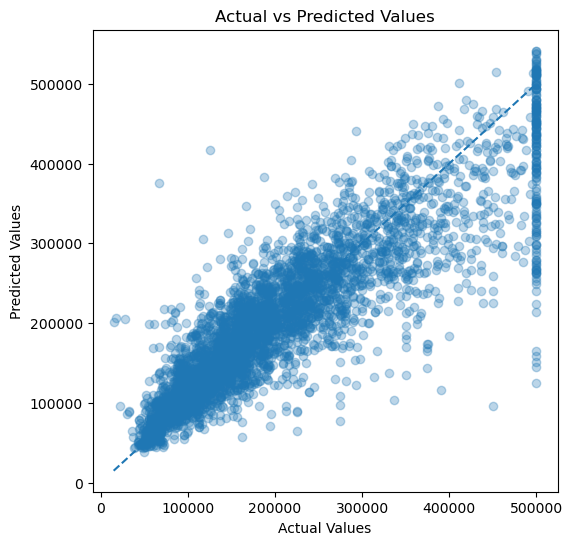

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
          linestyle='--'
         )
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

Effect of Learning rate

In [30]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.8]
results = []

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    
    results.append((lr, r2_score(y_test, preds)))
    
results_df = pd.DataFrame(results, columns=['Learning Rate', 'R2 Score'])
results_df

,Learning Rate,R2 Score
0,0.01,0.507628
1,0.05,0.705390
2,0.10,0.761670
3,0.20,0.788948
4,0.80,0.793571


In [31]:
depths = [1,2,3,4,6,7,8]
results = []

for d in depths:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=d,
        random_state=42
    )
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    
    results.append((d, r2_score(y_test, preds)))
    
results_df = pd.DataFrame(results, columns=['Max Depth', 'R2 Score'])
results_df

,Max Depth,R2 Score
0,1,0.615500
1,2,0.712707
2,3,0.761670
3,4,0.791932
4,6,0.818628
5,7,0.823634
6,8,0.826712


In [32]:
feature_importance = gbr.feature_importances_

importance_df = pd.Series(
    feature_importance, index=X.columns
).sort_values(ascending=False)

importance_df

median_income                 0.588018
ocean_proximity_INLAND        0.168416
longitude                     0.086303
latitude                      0.048448
housing_median_age            0.041398
population                    0.025039
total_bedrooms                0.021696
ocean_proximity_NEAR OCEAN    0.006269
households                    0.006032
ocean_proximity_NEAR BAY      0.005186
total_rooms                   0.003194
ocean_proximity_ISLAND        0.000000
dtype: float64